# Data cleaning

Kutubxonalarni yuklash va ma'lumotlarning dastlabki holatini o'rganish.
Birinchi navbatda pandas kutubxonasini yuklab, ma'lumotlarni o'qiymiz. Jadvallarning o'lchamini (qator va ustunlar sonini) chiqarib, ularning qanchalik kattaligini ko'zdan kechiramiz. Ustun nomlaridagi xatoliklarni to'g'rilab olamiz.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 

In [3]:
# Ma'lumotlarni yuklash
products = pd.read_csv('data/products.csv')
sales = pd.read_csv('data/sales.csv')

# Dastlabki o'lchamlarni ko'rish
print("Dastlabki products jadvali o'lchami:", products.shape)
print("Dastlabki sales jadvali o'lchami:", sales.shape)



Dastlabki products jadvali o'lchami: (10, 4)
Dastlabki sales jadvali o'lchami: (120000, 9)


Bo'sh (Missing) qiymatlarni tekshirish va tozalash.
Ma'lumotlar tahlilida bo'sh qiymatlar xato natijalarga olib kelishi mumkin. Avval har bir jadvalda nechta qatorda bo'sh qiymat borligini aniqlaymiz. Keyin ularni olib tashlab, qancha qator qisqarganini ekranga chiqaramiz.

In [4]:
# Bo'sh qiymatlarni sanash
print("Products jadvalidagi bo'sh qiymatlar soni:\n", products.isnull().sum())
print("\nSales jadvalidagi bo'sh qiymatlar soni:\n", sales.isnull().sum())



Products jadvalidagi bo'sh qiymatlar soni:
 product_id      0
product_name    0
category        0
cost_price      0
dtype: int64

Sales jadvalidagi bo'sh qiymatlar soni:
 order_id        0
customer_id     0
product_id      0
category        0
price           0
quantity        0
order_date      0
region          0
payment_type    0
dtype: int64


In [5]:
# agar bo'sh qiymati mavjud qatorlarni o'chirish
products.dropna(inplace=True)
sales.dropna(inplace=True)

print("\nBo'sh qiymatlar tozalanagandan keyingi o'lchamlar:")
print("Products:", products.shape)
print("Sales:", sales.shape)


Bo'sh qiymatlar tozalanagandan keyingi o'lchamlar:
Products: (10, 4)
Sales: (120000, 9)


Takroriy (Duplicate) qatorlarni aniqlash va o'chirish.
Bazada bir xil ma'lumotlar ikki marta tushib qolgan bo'lishi mumkin. Bunday yozuvlar sotuvlar hajmini sun'iy ravishda oshirib ko'rsatadi. Takroriy qatorlar sonini aniqlab, ularni jadvaldan o'chiramiz.

In [6]:
# Dublikatlarni sanash
products_duplicates = products.duplicated().sum()
sales_duplicates = sales.duplicated().sum()

print(f"Products jadvalidagi takroriy qatorlar soni: {products_duplicates}")
print(f"Sales jadvalidagi takroriy qatorlar soni: {sales_duplicates}")



Products jadvalidagi takroriy qatorlar soni: 0
Sales jadvalidagi takroriy qatorlar soni: 0


In [7]:
# Dublikatlarni o'chirish
products.drop_duplicates(inplace=True)
sales.drop_duplicates(inplace=True)

print("\nTakroriy qatorlar o'chirilgandan keyingi o'lchamlar:")
print("Products:", products.shape)
print("Sales:", sales.shape)


Takroriy qatorlar o'chirilgandan keyingi o'lchamlar:
Products: (10, 4)
Sales: (120000, 9)


Noto'g'ri narx yoki miqdorlarni aniqlash va tozalash.
Mantiqan, mahsulot narxi va sotilgan miqdor noldan katta bo'lishi shart. Agar ma'lumotlar bazasida 0 yoki undan kichik sonlar bo'lsa, bu kiritishdagi xatolik hisoblanadi. Bunday xato qatorlar sonini topib, ularni filtarlaymiz.

In [8]:
# Noto'g'ri qiymatlarni aniqlash
invalid_sales = sales[(sales['price'] <= 0) | (sales['quantity'] <= 0)].shape[0]
invalid_products = products[products['cost_price'] <= 0].shape[0]

print(f"Sales jadvalidagi noto'g'ri narx/miqdorga ega qatorlar soni: {invalid_sales}")
print(f"Products jadvalidagi noto'g'ri tannarxga ega qatorlar soni: {invalid_products}")

# Faqat to'g'ri qiymatlarni saqlab qolish
sales = sales[(sales['price'] > 0) & (sales['quantity'] > 0)]
products = products[products['cost_price'] > 0]

print("\nNoto'g'ri ma'lumotlar tozalangandan keyingi o'lchamlar:")
print("Products:", products.shape)
print("Sales:", sales.shape)

Sales jadvalidagi noto'g'ri narx/miqdorga ega qatorlar soni: 0
Products jadvalidagi noto'g'ri tannarxga ega qatorlar soni: 0

Noto'g'ri ma'lumotlar tozalangandan keyingi o'lchamlar:
Products: (10, 4)
Sales: (120000, 9)


Sanalarni normalize qilish.
Order_date ustuni odatda matn (string) ko'rinishida bo'ladi. Uni maxsus datetime formatiga o'tkazishimiz kerak, shunda vaqt boyicha tahlillar (masalan, oylik tushum) qilish osonlashadi. O'tkazish paytida xatolik beruvchi (noto'g'ri yozilgan) sanalarni ajratib olib, ularni ham tozalaymiz.

In [9]:
# Sanalarni o'zgartirishdan oldin ma'lumot turini ko'rish
print("Dastlabki order_date turi:", sales['order_date'].dtype)


Dastlabki order_date turi: str


In [10]:
# Datetime formatiga o'tkazish (xato sanalar NaT ga aylanadi)
sales['order_date'] = pd.to_datetime(sales['order_date'], errors='coerce')
print("Dastlabki order_date turi:", sales['order_date'].dtype)


Dastlabki order_date turi: datetime64[us]


In [11]:
# NaT (Not a Time) ga aylangan xato sanalar sonini aniqlash va o'chirish
invalid_dates = sales['order_date'].isnull().sum()
print(f"Noto'g'ri formatdagi sanalar soni (va o'chirildi): {invalid_dates}")

sales.dropna(subset=['order_date'], inplace=True)
print("Yangi order_date turi:", sales['order_date'].dtype)

Noto'g'ri formatdagi sanalar soni (va o'chirildi): 0
Yangi order_date turi: datetime64[us]


Moliyaviy ko'rsatkichlarni hisoblash: Revenue va Profit.
Yakuniy qadamda mahsulotlar tannarxini olish uchun jadvallarni birlashtiramiz. Birlashtirilgan jadvalda har bir xarid uchun umumiy tushum (Revenue) va sof foyda (Profit) hisoblanadi. Foydani hisoblashda mantiqan umumiy tushumdan barcha sotilgan mahsulotlarning umumiy tannarxi (cost_price * quantity) ayiriladi.

In [12]:
# Jadvallarni product_id orqali birlashtirish (chapga qo'shish)
# Category ikkala jadvalda bo'lgani uchun chalkashlik bo'lmasligi uchun uni products dan olmaymiz
merged_df = sales.merge(products[['product_id', 'cost_price']], on='product_id', how='left')

# Birlashtirish natijasida cost_price topilmagan yozuvlar bor-yo'qligini tekshirish
missing_costs = merged_df['cost_price'].isnull().sum()
print(f"Bazasida tannarxi topilmagan sotuvlar soni: {missing_costs}")
merged_df.dropna(subset=['cost_price'], inplace=True)


Bazasida tannarxi topilmagan sotuvlar soni: 0


In [13]:
# Tushum va foydani hisoblash
merged_df['revenue'] = merged_df['price'] * merged_df['quantity']

# Umumiy tushumdan umumiy tannarxni ayirish
merged_df['profit'] = merged_df['revenue'] - (merged_df['cost_price'] * merged_df['quantity'])

# Natijani tekshirish
print("\nYakuniy jadvalning dastlabki 5 qatori:")
print(merged_df[['order_id', 'product_id', 'quantity', 'revenue', 'profit']].head())


Yakuniy jadvalning dastlabki 5 qatori:
   order_id product_id  quantity  revenue  profit
0         1       P004         5   410.70  135.70
1         2       P007         2     0.72    0.12
2         3       P009         1    38.60   13.60
3         4       P003         5   277.40   77.40
4         5       P001         2  1792.82  592.82


# Dada Analitics

Kerakli kutubxonalarni yuklash va Biznes Metrikalarni hisoblash.
Ma'lumotlarni vizualizatsiya qilish uchun Pythonning matplotlib va seaborn kutubxonalaridan foydalanamiz. Birinchi qadamda biznesning umumiy holatini ko'rsatuvchi tushum, foyda va xarajatni hisoblaymiz. Ularning nisbatini yaqqol ko'rish uchun ustunli grafik (bar chart) chizamiz. Bu rahbariyatga pul qayerdan kelib, qanchasi sof foyda bo'lib qolayotganini tushunishga yordam beradi.

Umumiy tushum (Total Revenue): 63,338,820.15
Umumiy foyda (Total Profit): 19,682,845.45
Foyda marjasi (Profit Margin): 31.08%



C:\Users\Javoxir\AppData\Local\Temp\ipykernel_2248\1323900310.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Total Revenue', 'Total Cost', 'Total Profit'],


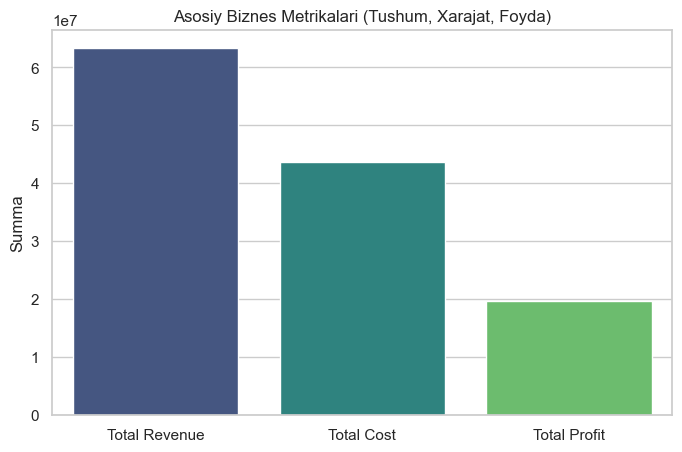

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklar uslubini zamonaviy va toza qilib sozlash
sns.set_theme(style="whitegrid")

# Metrikalarni hisoblash
total_revenue = merged_df['revenue'].sum()
total_profit = merged_df['profit'].sum()
total_cost = total_revenue - total_profit
profit_margin = (total_profit / total_revenue) * 100

# Raqamli natijalarni konsolga chiqarish
print(f"Umumiy tushum (Total Revenue): {total_revenue:,.2f}")
print(f"Umumiy foyda (Total Profit): {total_profit:,.2f}")
print(f"Foyda marjasi (Profit Margin): {profit_margin:.2f}%\n")

# Vizualizatsiya: Tushum tarkibi
plt.figure(figsize=(8, 5))
# Daromad, Xarajat va Foydani yonma-yon solishtirish
sns.barplot(x=['Total Revenue', 'Total Cost', 'Total Profit'], 
            y=[total_revenue, total_cost, total_profit], 
            palette='viridis')

plt.title('Asosiy Biznes Metrikalari (Tushum, Xarajat, Foyda)')
plt.ylabel('Summa')
plt.show()

Samaradorlikni baholash (Performance Analytics).
Tizimdagi kuchli va zaif nuqtalarni aniqlash biznes strategiyasi uchun muhim. Ushbu qadamda Top 10 mahsulotni, toifalar bo'yicha foydani va hududlar bo'yicha tushumni hisoblaymiz. Bularni bitta umumiy oynada 3 ta alohida gorizontal ustunli grafikda tasvirlaymiz. Gorizontal grafiklar uzun nomli mahsulot va hududlarni o'qish uchun eng qulay usul hisoblanadi. Shunday qilib, qaysi hudud eng past ko'rsatkichga ega ekanligi avtomatik yaqqol ko'rinadi.

Eng foydali kategoriya: Electronics
Eng past performance hudud: Andijan 



C:\Users\Javoxir\AppData\Local\Temp\ipykernel_2248\2549704135.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_products.values, y=top_10_products.index, ax=axes[0], palette='Blues_r')
C:\Users\Javoxir\AppData\Local\Temp\ipykernel_2248\2549704135.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_profit.values, y=category_profit.index, ax=axes[1], palette='Greens_r')
C:\Users\Javoxir\AppData\Local\Temp\ipykernel_2248\2549704135.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_revenue.values, y=region_rev

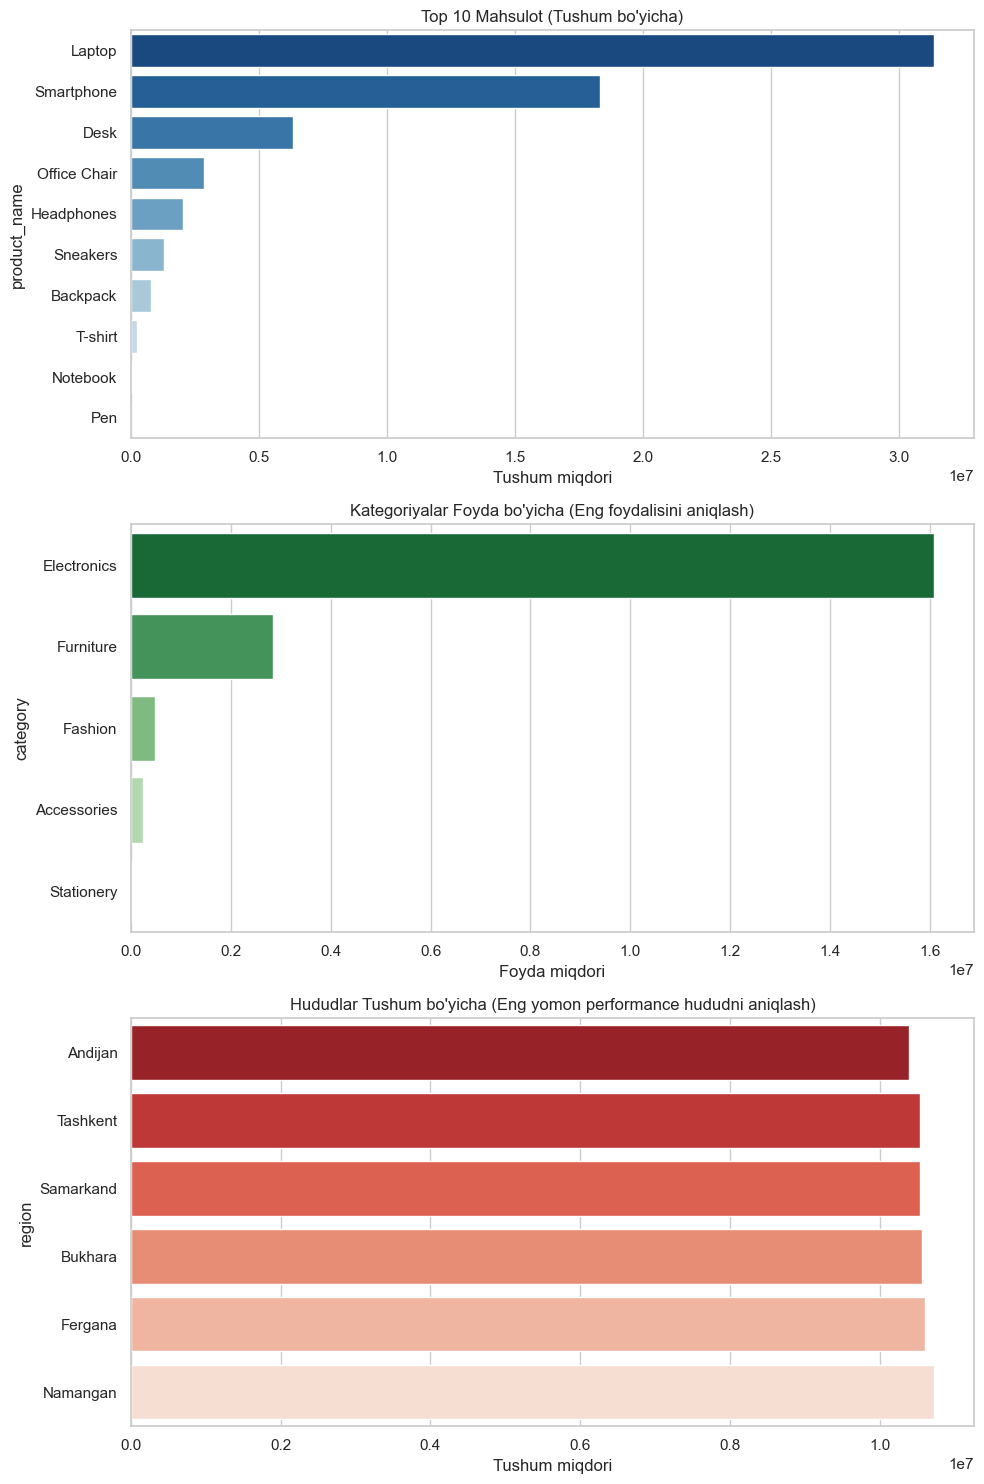

In [15]:
# Agar product_name ustuni yo'q bo'lsa, uni products jadvalidan olib kelamiz
if 'product_name' not in merged_df.columns:
    merged_df = merged_df.merge(products[['product_id', 'product_name']], on='product_id', how='left')

# 1. Top 10 mahsulot (Tushum bo'yicha)
top_10_products = merged_df.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)

# 2. Toifalar bo'yicha foyda (Profit)
category_profit = merged_df.groupby('category')['profit'].sum().sort_values(ascending=False)

# 3. Hududlar bo'yicha tushum (Revenue) - Eng pastini ko'rish uchun o'sish tartibida taxlaymiz
region_revenue = merged_df.groupby('region')['revenue'].sum().sort_values(ascending=True)

# Natijalarni konsolga chiqarish
print("Eng foydali kategoriya:", category_profit.index[0])
print("Eng past performance hudud:", region_revenue.index[0], "\n")

# Vizualizatsiya oynasini tayyorlash (3 qator, 1 ustun)
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Top 10 mahsulot grafigi
sns.barplot(x=top_10_products.values, y=top_10_products.index, ax=axes[0], palette='Blues_r')
axes[0].set_title("Top 10 Mahsulot (Tushum bo'yicha)")
axes[0].set_xlabel("Tushum miqdori")

# Kategoriyalar foyda bo'yicha
sns.barplot(x=category_profit.values, y=category_profit.index, ax=axes[1], palette='Greens_r')
axes[1].set_title("Kategoriyalar Foyda bo'yicha (Eng foydalisini aniqlash)")
axes[1].set_xlabel("Foyda miqdori")

# Hududlar tushum bo'yicha
sns.barplot(x=region_revenue.values, y=region_revenue.index, ax=axes[2], palette='Reds_r')
axes[2].set_title("Hududlar Tushum bo'yicha (Eng yomon performance hududni aniqlash)")
axes[2].set_xlabel("Tushum miqdori")

# Grafiklarni tartibli joylashtirish
plt.tight_layout()
plt.show()

Trendlar va xatti-harakatlar taqsimoti (Trends and Distributions).
Vaqt o'tishi bilan savdolar qanday o'zgarayotganini tushunish uchun oylik tushum trendini chiziqli grafikda (line chart) chizamiz. Mijozlarning xarid odatlarini aniqlash uchun ish kunlari va dam olish kunlaridagi savdo hajmini, shuningdek to'lov turlarini (naqd, karta va h.k.) doiraviy diagrammalarda (pie chart) foiz hisobida tasvirlaymiz.

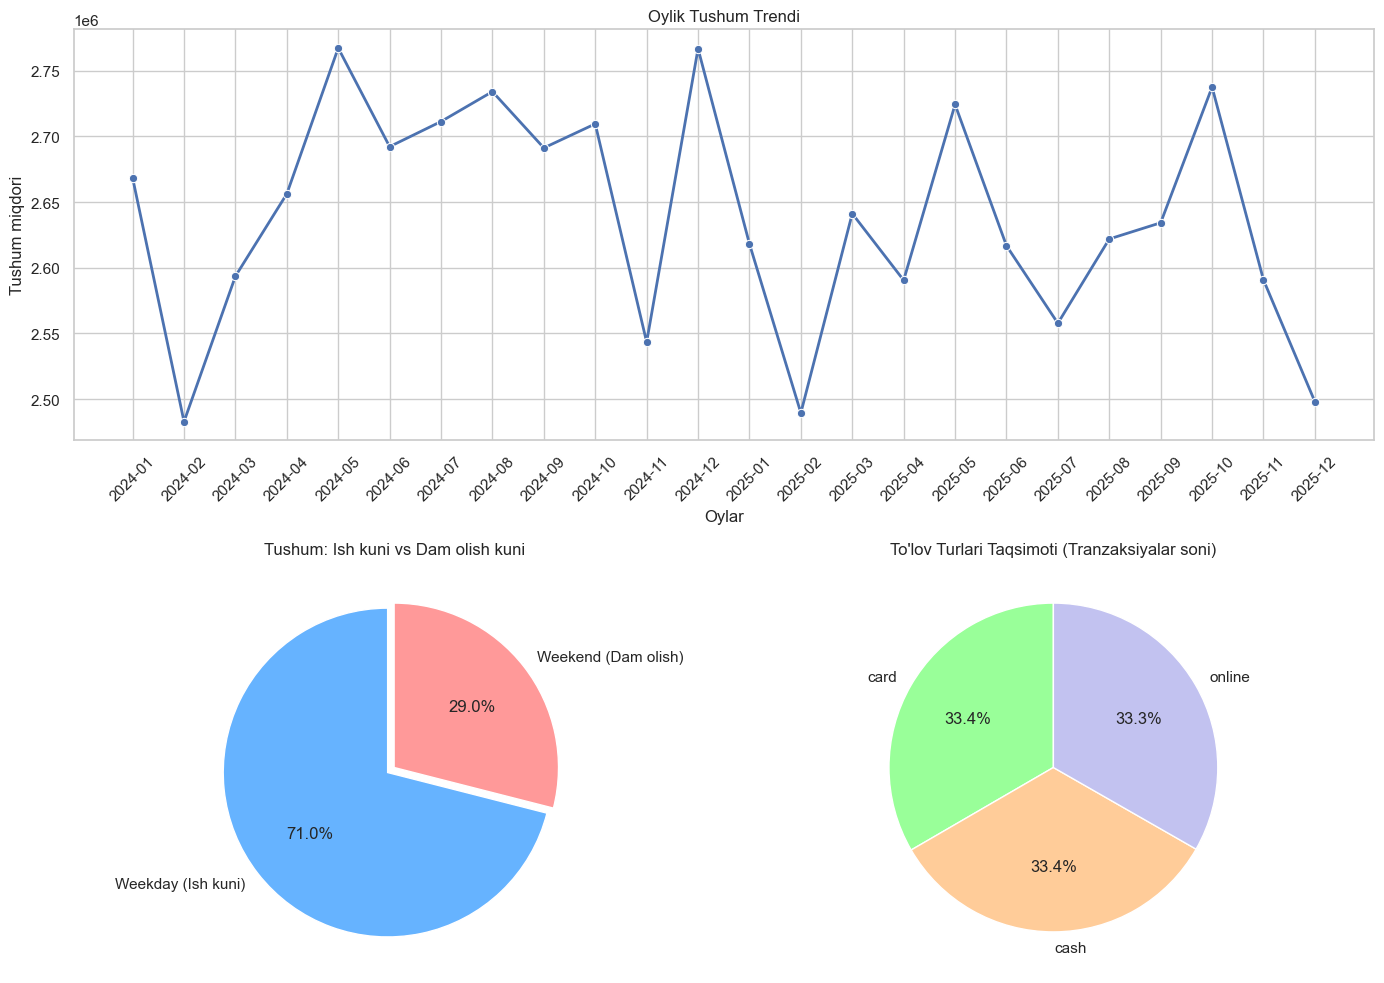

In [16]:
# Sanalardan oy nomini va hafta kunini ajratib olish
merged_df['month'] = merged_df['order_date'].dt.to_period('M').astype(str)
merged_df['day_of_week'] = merged_df['order_date'].dt.dayofweek

# 5 va 6 - Shanba hamda Yakshanba kunlari hisoblanadi
merged_df['day_type'] = merged_df['day_of_week'].isin([5, 6]).map({True: 'Weekend (Dam olish)', False: 'Weekday (Ish kuni)'})

# Ma'lumotlarni guruhlash
monthly_trend = merged_df.groupby('month')['revenue'].sum()
weekend_vs_weekday = merged_df.groupby('day_type')['revenue'].sum()
payment_distribution = merged_df['payment_type'].value_counts()

# Vizualizatsiya oynasi (Tepada 1 ta uzun grafik, pastda 2 ta doiraviy grafik)
fig = plt.figure(figsize=(14, 10))

# 1. Oylik trend (Chiziqli grafik)
ax1 = fig.add_subplot(2, 1, 1)
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker='o', color='b', ax=ax1, linewidth=2)
ax1.set_title("Oylik Tushum Trendi")
ax1.set_ylabel("Tushum miqdori")
ax1.set_xlabel("Oylar")
plt.xticks(rotation=45)

# 2. Ish kuni va Dam olish kuni (Doiraviy grafik)
ax2 = fig.add_subplot(2, 2, 3)
ax2.pie(weekend_vs_weekday, labels=weekend_vs_weekday.index, autopct='%1.1f%%', 
        colors=['#66b3ff', '#ff9999'], startangle=90, explode=(0.05, 0))
ax2.set_title("Tushum: Ish kuni vs Dam olish kuni")

# 3. To'lov turlari (Doiraviy grafik)
ax3 = fig.add_subplot(2, 2, 4)
ax3.pie(payment_distribution, labels=payment_distribution.index, autopct='%1.1f%%', 
        colors=['#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6'], startangle=90)
ax3.set_title("To'lov Turlari Taqsimoti (Tranzaksiyalar soni)")

plt.tight_layout()
plt.show()

2-bosqich (Data Analytics) bo'yicha yakuniy biznes xulosasi va strategik tavsiyalar
Ushbu tahliliy bosqich kompaniyaning joriy tijorat holatini chuqur tushunish va kelgusidagi strategik qarorlarni qabul qilish uchun xizmat qiladi. Olingan natijalar va vizualizatsiyalar biznesning kuchli tomonlarini va o'sish uchun potensial hududlarni yaqqol ko'rsatib berdi.

1. Moliyaviy barqarorlik va Narx siyosati
Kompaniyaning umumiy tushumi va xarajatlari nisbatida shakllangan 31.08% lik sof foyda marjasi (Profit Margin) biznesning moliya va operatsion boshqaruvi juda sog'lom ekanligini bildiradi. Bu ko'rsatkich mahsulotlarga to'g'ri ustama (nakrutka) qilinganini va xarajatlar nazoratga olinganini anglatadi. Biznes kelgusida yangi hududlarga kengayish yoki marketing kampaniyalari uchun o'zini o'zi yetarli sarmoya bilan ta'minlay oladi.

2. Asosiy daromad drayverlari (Mahsulot va Toifalar)
Tahlillar shuni ko'rsatmoqdaki, biznesning asosiy drayveri "Electronics" (Elektronika) toifasi hisoblanadi. Mijozlarning asosiy xaridlari va eng yuqori foyda aynan shu yo'nalishdan kelmoqda.

Strategik qadam: "Top 10" eng ko'p sotilayotgan mahsulotlar va elektronika toifasi omborda doimiy yetarli zaxiraga ega bo'lishi shart (Out-of-stock xavfini oldini olish). Shuningdek, mijozlar oqimidan foydalanib, ushbu toifaga yondosh (kross-seling) aksessuarlarni taklif qilish orqali o'rtacha chek (AOV) miqdorini yanada oshirish mumkin.

3. Mintaqaviy rivojlanishdagi bo'shliqlar
Hududlar bo'yicha tushum tahlili Andijon viloyatida savdo ko'rsatkichlari boshqa hududlarga nisbatan ancha past ekanligini ko'rsatdi. Bu bozorning xarid qobiliyati pastligini emas, balki yetkazib berishdagi logistik qiyinchiliklar, ushbu hududda reklama yetarli emasligi yoki brend xabardorligi pastligini anglatishi mumkin.

Strategik qadam: Andijon hududi uchun maxsus yetkazib berish chegirmalari, lokal (hududiy) ijtimoiy tarmoq reklamalari (Targeting) va dilerlik tarmoqlarini qayta ko'rib chiqish tavsiya etiladi. Oqsab turgan hududni ko'tarish umumiy tushumning keskin o'sishiga olib keladi.

4. Mijozlar xulq-atvori va Xarid trendlari
Oylik savdo dinamikasi barqaror o'sishni emas, balki ma'lum bir tebranishlarni (mavsumiylikni) ko'rsatmoqda. Hafta kunlari (ish va dam olish kunlari) hamda to'lov turlari taqsimoti (Payment types) bizga mijozlarning xarid odatlarini ochib berdi.

Strategik qadam: Marketing byudjetini savdolar eng ko'p amalga oshadigan kunlar va oylarga qarab moslashtirish (dinamik byudjet taqsimoti) reklama xarajatlarini optimallashtiradi. Ommabop to'lov tizimlari orqali ishlash barqarorligini ta'minlash mijozlar tranzaksiyani bekor qilishining (Cart abandonment) oldini oladi.

Umumiy xulosa: Biznes to'g'ri va daromadli yo'nalishda harakatlanmoqda. Mavjud barqarorlikni saqlab qolgan holda, endigi asosiy fokus – past ko'rsatkichli hududlarni rivojlantirish va talab yuqori bo'lgan mahsulotlar qatorini yanada boyitishga qaratilishi lozim.

# Forecasting


Ma'lumotlarni vaqtli qatorlar (Time-Series) ko'rinishida tayyorlash va oylik guruhlash.
Kelajakdagi savdo hajmini bashorat qilish uchun kunlik ma'lumotlar juda ko'p "shovqin" (tebranishlar) ga ega bo'ladi. Shu sababli, prognoz modellariga ma'lumot uzatishdan oldin, barcha tranzaksiyalarni oylar kesimida umumlashtirib olishimiz kerak. Bu qadamda biz har bir oy uchun umumiy tushum, sotilgan tovarlar miqdori va sof foydani, shuningdek, toifalar bo'yicha oylik natijalarni alohida jadvallarga yig'ib olamiz. Bu kelgusi 2026-yil yanvar oyini bashorat qilish uchun tarixiy poydevor vazifasini o'taydi.

In [17]:

df = merged_df.copy()
df['year_month'] = df['order_date'].dt.to_period('M')

In [18]:
# 1. Umumiy oylik ko'rsatkichlar
monthly = df.groupby('year_month').agg(
    revenue  = ('revenue',  'sum'),
    quantity = ('quantity', 'sum'),
    profit   = ('profit',   'sum')
).reset_index()

monthly['year_month'] = monthly['year_month'].dt.to_timestamp()
monthly = monthly.sort_values('year_month')

print("=== OYLIK UMUMIY KO'RSATKICHLAR ===")
print(monthly.to_string(index=False))

# 2. Kategoriya bo'yicha oylik revenue
cat_monthly = df.groupby(['year_month', 'category'])['revenue'].sum().reset_index()
cat_monthly['year_month'] = cat_monthly['year_month'].dt.to_timestamp()
cat_monthly = cat_monthly.sort_values(['category', 'year_month'])

print("\n=== KATEGORIYA BO'YICHA OYLIK REVENUE (dastlabki 10 qator) ===")
print(cat_monthly.head(10).to_string(index=False))

=== OYLIK UMUMIY KO'RSATKICHLAR ===
year_month    revenue  quantity    profit
2024-01-01 2668485.26     15193 836080.96
2024-02-01 2482840.32     14103 780609.02
2024-03-01 2593573.92     15087 814042.42
2024-04-01 2656318.18     14992 831391.68
2024-05-01 2767374.67     15492 845402.37
2024-06-01 2692257.42     14545 838503.52
2024-07-01 2711393.39     15243 841699.89
2024-08-01 2734178.07     15465 844131.47
2024-09-01 2691305.04     14558 827439.94
2024-10-01 2709617.11     15549 832832.11
2024-11-01 2543404.26     14583 789600.56
2024-12-01 2766891.43     15273 870889.13
2025-01-01 2618236.61     15242 817058.41
2025-02-01 2489496.18     14000 775327.38
2025-03-01 2641288.47     15399 815316.87
2025-04-01 2590524.73     14445 805232.53
2025-05-01 2724364.75     15081 850711.35
2025-06-01 2616832.83     14919 818964.03
2025-07-01 2557772.21     14999 789831.91
2025-08-01 2621955.14     15336 816613.64
2025-09-01 2634289.78     14867 812320.98
2025-10-01 2737606.90     15622 842385.5

Chiziqli Regressiya (Linear Regression) yordamida dastlabki bashorat.
Ushbu qadamda biz kelajakni bashorat qilish uchun klassik Mashinali o'qitish (Machine Learning) modeli bo'lgan Chiziqli Regressiyadan foydalanamiz. Bu model vaqt o'tishi bilan savdolar doimiy ravishda o'sib yoki kamayib borayotganini tekshiradi va shunga asoslanib 2026-yil yanvar oyi uchun raqamlarni taqdim etadi. Modelning ishonchliligini $R^2$ (R-squared) metrikasi orqali baholaymiz. Agar savdolar barqaror o'sayotgan bo'lsa, bu ko'rsatkich yuqori chiqadi, ammo mavsumiylik va tebranishlar kuchli bo'lsa, chiziqli model past aniqlik ko'rsatishi mumkin.

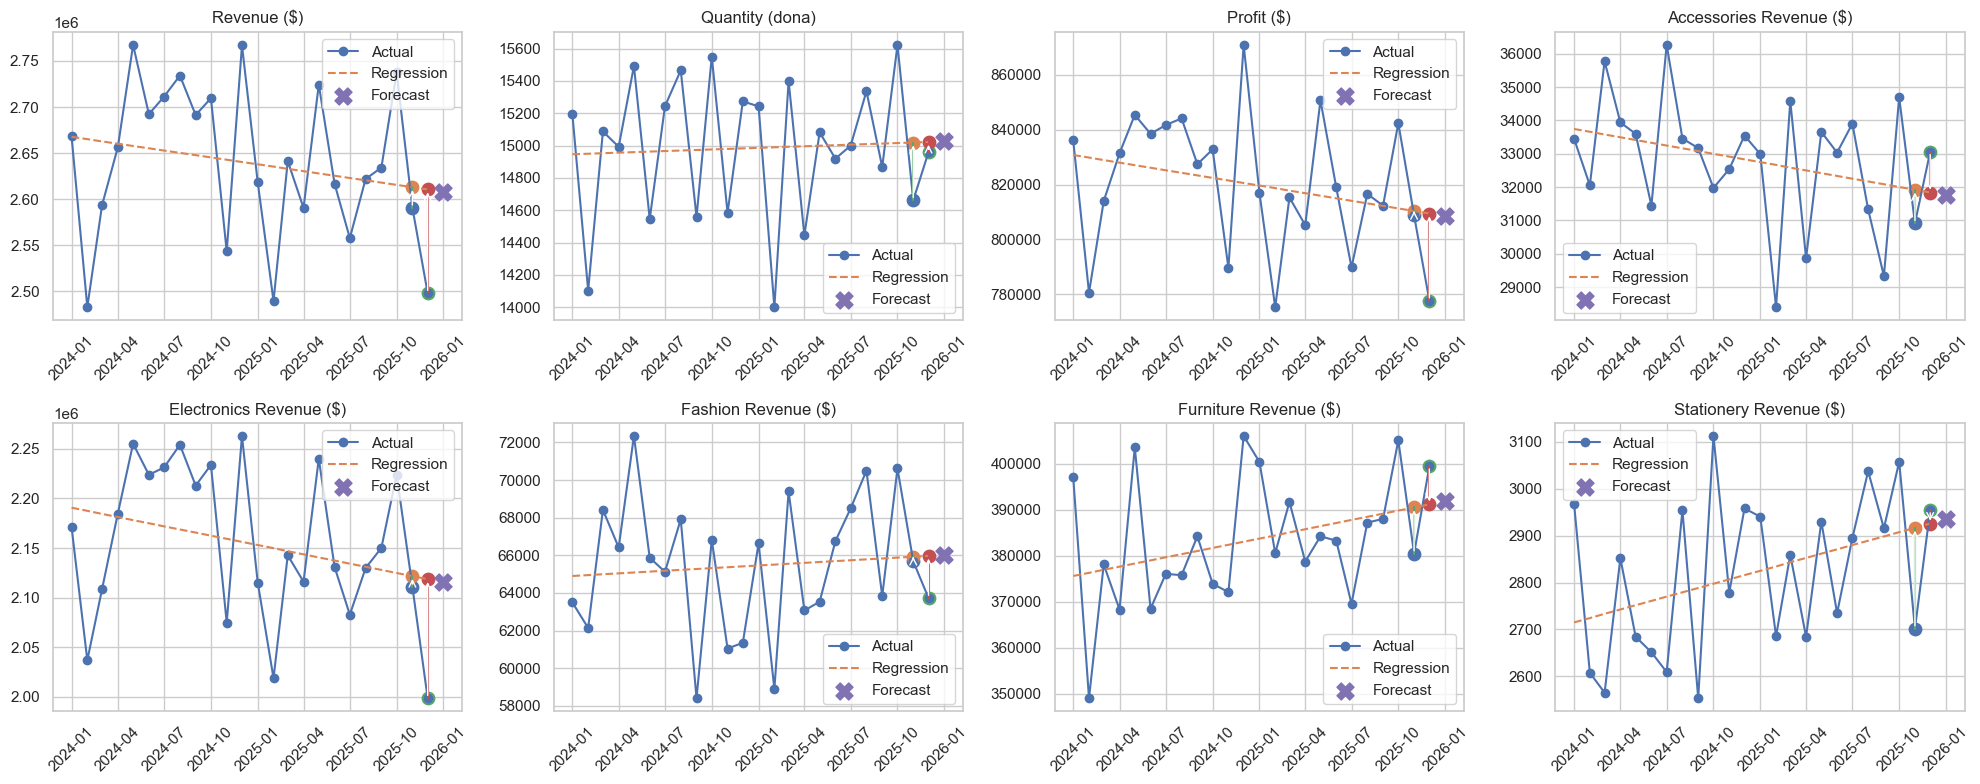


=== PROGNOZ NATIJALARI ===

+-------------------------+------------------+------------------+-------------+------------------+------------------+-------------+------------------+-------+----------+
| Metric                  |         Real(-2) |         Pred(-2) |   Error(-2) |         Real(-1) |         Pred(-1) |   Error(-1) |   Forecast(next) |    R2 |      MAE |
+=========================+==================+==================+=============+==================+==================+=============+==================+=======+==========+
| Revenue ($)             |      2.59078e+06 |      2.61306e+06 |   -22286.7  |      2.49804e+06 |      2.61058e+06 |  -112545    |       2.6081e+06 | 0.043 | 64075.6  |
+-------------------------+------------------+------------------+-------------+------------------+------------------+-------------+------------------+-------+----------+
| Quantity (dona)         |  14661           |  15018.6         |     -357.56 |  14959           |  15021.9         |    

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from tabulate import tabulate


results = []
plots_data = []


def forecast_next_month(data, date_col, value_col, label):

    data = data.sort_values(date_col).reset_index(drop=True)

    X = np.array(data.index + 1).reshape(-1, 1)
    y = data[value_col].values

    model = LinearRegression()
    model.fit(X, y)

    pred = model.predict(X)

    next_month_num = np.array([[len(data) + 1]])
    forecast = model.predict(next_month_num)[0]

    r2 = model.score(X, y)
    mae = mean_absolute_error(y, pred)

    # oxirgi 2 ta qiymat
    last_real_1 = y[-2]
    last_real_2 = y[-1]

    last_pred_1 = pred[-2]
    last_pred_2 = pred[-1]

    err1 = last_real_1 - last_pred_1
    err2 = last_real_2 - last_pred_2

    results.append({
        "Metric": label,
        "Real(-2)": round(last_real_1,2),
        "Pred(-2)": round(last_pred_1,2),
        "Error(-2)": round(err1,2),

        "Real(-1)": round(last_real_2,2),
        "Pred(-1)": round(last_pred_2,2),
        "Error(-1)": round(err2,2),

        "Forecast(next)": round(forecast,2),
        "R2": round(r2,3),
        "MAE": round(mae,2)
    })

    plots_data.append({
        "label": label,
        "data": data,
        "y": y,
        "pred": pred,
        "forecast": forecast,
        "date_col": date_col
    })


# ===== umumiy ko‘rsatkichlar =====

forecast_next_month(monthly, 'year_month', 'revenue',  'Revenue ($)')
forecast_next_month(monthly, 'year_month', 'quantity', 'Quantity (dona)')
forecast_next_month(monthly, 'year_month', 'profit',   'Profit ($)')


# ===== kategoriya bo‘yicha =====

categories = cat_monthly['category'].unique()

for cat in sorted(categories):
    cat_data = cat_monthly[cat_monthly['category'] == cat].copy()
    forecast_next_month(cat_data, 'year_month', 'revenue', f'{cat} Revenue ($)')


# =========================
# GRAFIKLAR
# =========================

n = len(plots_data)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4*rows))
axes = axes.flatten()

for i, plot in enumerate(plots_data):

    ax = axes[i]

    data = plot["data"]
    y = plot["y"]
    pred = plot["pred"]
    forecast = plot["forecast"]
    dates = data[plot["date_col"]]

    # haqiqiy qiymatlar
    ax.plot(dates, y, marker='o', label="Actual")

    # regression
    ax.plot(dates, pred, linestyle="--", label="Regression")

    # oxirgi 2 ta nuqtada error ko‘rsatish
    for idx in [-2, -1]:

        x = dates.iloc[idx]

        actual_val = y[idx]
        pred_val = pred[idx]

        ax.scatter(x, actual_val, s=80)
        ax.scatter(x, pred_val, s=80)

        ax.plot([x, x], [actual_val, pred_val])

        ax.annotate(
            '',
            xy=(x, pred_val),
            xytext=(x, actual_val),
            arrowprops=dict(arrowstyle="->")
        )

    # forecast nuqta
    next_date = dates.iloc[-1] + pd.DateOffset(months=1)

    ax.scatter(
        next_date,
        forecast,
        marker='X',
        s=150,
        label="Forecast"
    )

    ax.set_title(plot["label"])
    ax.tick_params(axis='x', rotation=45)
    ax.legend()


for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# =========================
# JADVAL
# =========================

result_df = pd.DataFrame(results)

print("\n=== PROGNOZ NATIJALARI ===\n")

print(
    tabulate(
        result_df,
        headers="keys",
        tablefmt="grid",
        showindex=False
    )
)

In [ ]:
# from sklearn.linear_model import LinearRegression

# def forecast_next_month(data, date_col, value_col, label):
#     data = data.sort_values(date_col).reset_index(drop=True)
#     X = np.array(data.index + 1).reshape(-1, 1)
#     y = data[value_col].values
    
#     model = LinearRegression()
#     model.fit(X, y)
    
#     next_month_num = np.array([[len(data) + 1]])
#     forecast = model.predict(next_month_num)[0]
#     r2 = model.score(X, y)
    
#     print(f"{label:30s} | Prognoz: {forecast:>12,.0f} | R2 score: {r2:.3f}")
#     return forecast

# print("=== 2026-YANVAR PROGNOZI (Linear Regression) ===")
# header = "Ko'rsatkich"
# print(f"{header:30s} | {'Prognoz':>12s} | Aniqlik")
# print("-" * 60)

# # Umumiy ko'rsatkichlar
# rev_forecast  = forecast_next_month(monthly, 'year_month', 'revenue',  'Revenue ($)')
# qty_forecast  = forecast_next_month(monthly, 'year_month', 'quantity', 'Quantity (dona)')
# prof_forecast = forecast_next_month(monthly, 'year_month', 'profit',   'Profit ($)')

# print("-" * 60)

# # Kategoriya bo'yicha
# print("\n--- KATEGORIYALAR BO'YICHA ---")
# categories = cat_monthly['category'].unique()
# for cat in sorted(categories):
#     cat_data = cat_monthly[cat_monthly['category'] == cat].copy()
#     forecast_next_month(cat_data, 'year_month', 'revenue', f'{cat} Revenue ($)')

=== 2026-YANVAR PROGNOZI (Linear Regression) ===
Ko'rsatkich                    |      Prognoz | Aniqlik
------------------------------------------------------------
Revenue ($)                    | Prognoz:    2,608,101 | R2 score: 0.043
Quantity (dona)                | Prognoz:       15,025 | R2 score: 0.003
Profit ($)                     | Prognoz:      808,529 | R2 score: 0.069
------------------------------------------------------------

--- KATEGORIYALAR BO'YICHA ---
Accessories Revenue ($)        | Prognoz:       31,754 | R2 score: 0.096
Electronics Revenue ($)        | Prognoz:    2,115,499 | R2 score: 0.080
Fashion Revenue ($)            | Prognoz:       66,016 | R2 score: 0.008
Furniture Revenue ($)          | Prognoz:      391,898 | R2 score: 0.119
Stationery Revenue ($)         | Prognoz:        2,935 | R2 score: 0.150


O'rtacha Siljuvchi (Moving Average) metodi va Modellarni taqqoslash.
Chakana savdoda ko'pincha keyingi oyning natijasi undan oldingi oylarning momentumiga (jarayoniga) bog'liq bo'ladi. Shuning uchun, oxirgi 3 oylik savdolarning o'rtacha qiymatiga asoslangan "Moving Average" usulini qo'llaymiz. Shuningdek, bu modelning haqiqatga qanchalik yaqinligini bilish uchun O'rtacha foizlik xatolikni (MAPE) hisoblaymiz. Qadam yakunida rahbariyat oson qaror qabul qilishi uchun ikkala modelning natijalarini yonma-yon taqqoslaymiz.

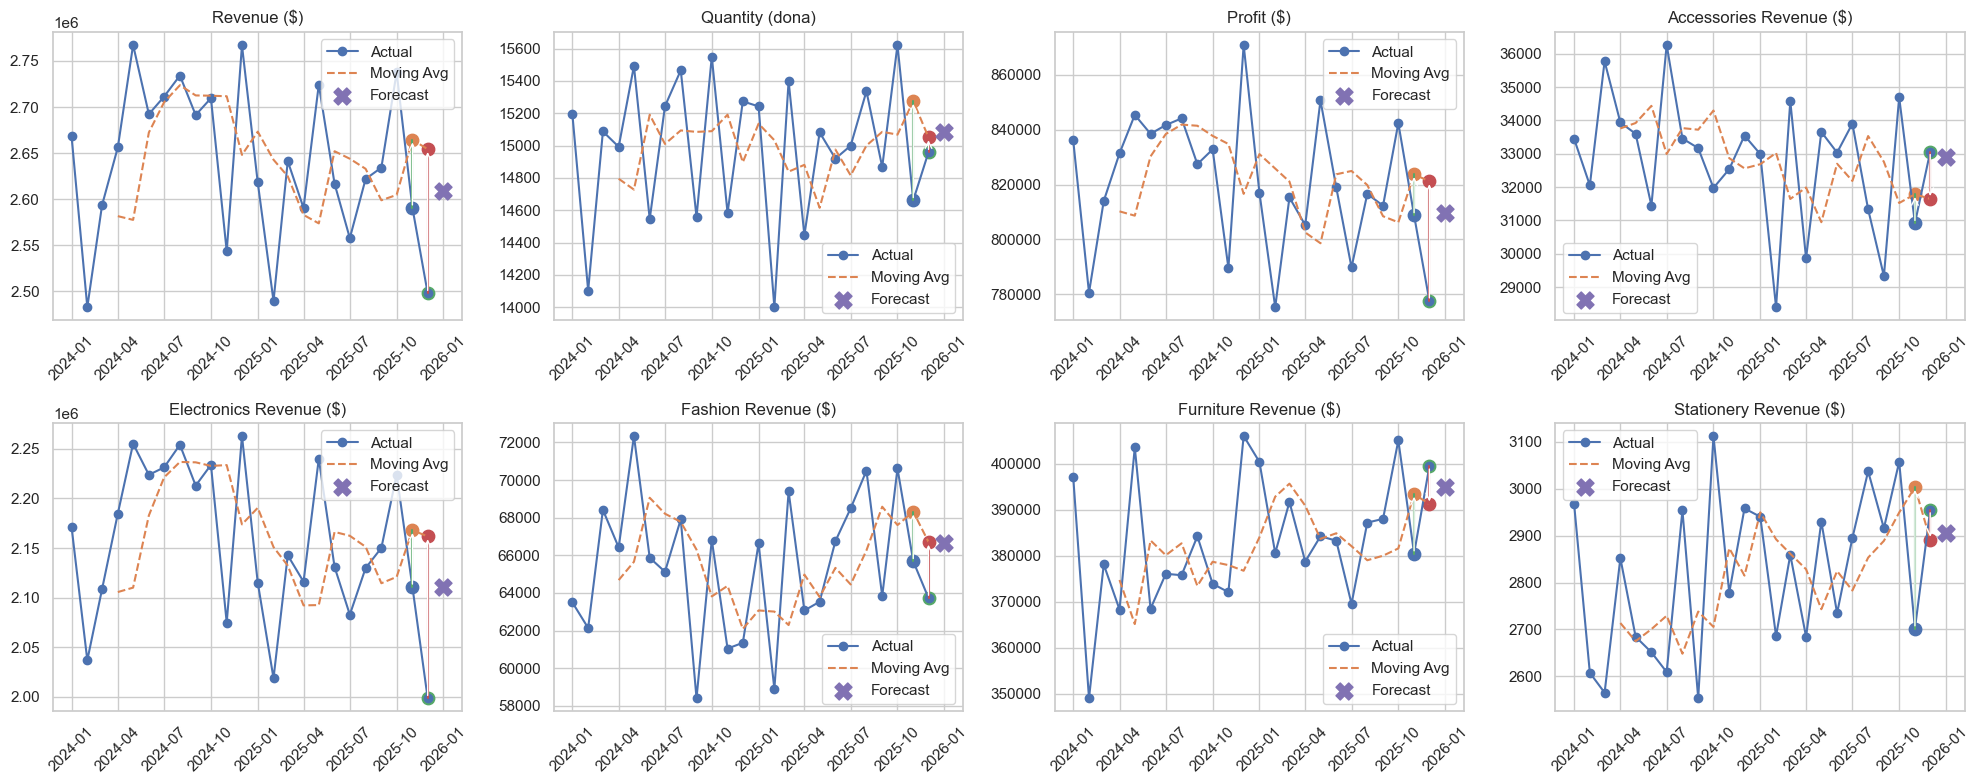


=== MOVING AVERAGE NATIJALARI ===

+-------------------------+------------------+------------------+-------------+------------------+------------------+-------------+------------------+----------+
| Metric                  |         Real(-2) |         Pred(-2) |   Error(-2) |         Real(-1) |         Pred(-1) |   Error(-1) |   Forecast(next) |   MAPE % |
+=========================+==================+==================+=============+==================+==================+=============+==================+==========+
| Revenue ($)             |      2.59078e+06 |      2.66462e+06 |  -73840.5   |      2.49804e+06 |      2.65422e+06 |  -156188    |      2.60881e+06 |  2.7598  |
+-------------------------+------------------+------------------+-------------+------------------+------------------+-------------+------------------+----------+
| Quantity (dona)         |  14661           |  15275           |    -614     |  14959           |  15050           |      -91    |  15080.7         |  2.

In [21]:


ma_results = []
ma_plots = []


def forecast_moving_average(data, date_col, value_col, label, window=3):

    data = data.sort_values(date_col).reset_index(drop=True)
    y = data[value_col].values

    preds = []

    for i in range(len(y)):
        if i < window:
            preds.append(np.nan)
        else:
            preds.append(np.mean(y[i-window:i]))

    preds = np.array(preds)

    forecast = np.mean(y[-window:])

    errors = []
    for i in range(window, len(y)):
        errors.append(abs(preds[i] - y[i]) / y[i] * 100)

    mape = np.mean(errors)

    ma_results.append({
        "Metric": label,
        "Real(-2)": y[-2],
        "Pred(-2)": preds[-2],
        "Error(-2)": y[-2] - preds[-2],
        "Real(-1)": y[-1],
        "Pred(-1)": preds[-1],
        "Error(-1)": y[-1] - preds[-1],
        "Forecast(next)": forecast,
        "MAPE %": mape
    })

    ma_plots.append({
        "label": label,
        "data": data,
        "y": y,
        "pred": preds,
        "forecast": forecast,
        "date_col": date_col
    })

    return forecast


# =========================
# MODELNI ISHLATISH
# =========================

rev_ma  = forecast_moving_average(monthly, 'year_month', 'revenue',  'Revenue ($)')
qty_ma  = forecast_moving_average(monthly, 'year_month', 'quantity', 'Quantity (dona)')
prof_ma = forecast_moving_average(monthly, 'year_month', 'profit',   'Profit ($)')


for cat in sorted(cat_monthly['category'].unique()):
    cat_data = cat_monthly[cat_monthly['category'] == cat].copy()
    forecast_moving_average(cat_data, 'year_month', 'revenue', f'{cat} Revenue ($)')


# =========================
# GRAFIKLAR
# =========================

n = len(ma_plots)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, plot in enumerate(ma_plots):

    ax = axes[i]

    data = plot["data"]
    y = plot["y"]
    pred = plot["pred"]
    forecast = plot["forecast"]
    dates = data[plot["date_col"]]

    # actual
    ax.plot(dates, y, marker='o', label="Actual")

    # moving average prediction
    ax.plot(dates, pred, linestyle="--", label="Moving Avg")

    # oxirgi 2 ta nuqtada xatolik ko‘rsatish
    for idx in [-2, -1]:

        x = dates.iloc[idx]

        actual_val = y[idx]
        pred_val = pred[idx]

        ax.scatter(x, actual_val, s=80)
        ax.scatter(x, pred_val, s=80)

        ax.plot([x, x], [actual_val, pred_val])

        ax.annotate(
            '',
            xy=(x, pred_val),
            xytext=(x, actual_val),
            arrowprops=dict(arrowstyle="->")
        )

    # forecast nuqta
    next_date = dates.iloc[-1] + pd.DateOffset(months=1)

    ax.scatter(
        next_date,
        forecast,
        marker='X',
        s=150,
        label="Forecast"
    )

    ax.set_title(plot["label"])
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# =========================
# JADVAL
# =========================

result_df = pd.DataFrame(ma_results)

print("\n=== MOVING AVERAGE NATIJALARI ===\n")

print(
    tabulate(
        result_df,
        headers="keys",
        tablefmt="grid",
        showindex=False
    )
)

In [ ]:
# def forecast_moving_average(data, date_col, value_col, label, window=3):
#     data = data.sort_values(date_col).reset_index(drop=True)
#     y = data[value_col].values
    
   
#     forecast = np.mean(y[-window:])
    
    
#     errors = []
#     for i in range(6, len(y)):
#         predicted = np.mean(y[i-window:i])
#         actual = y[i]
#         errors.append(abs(predicted - actual) / actual * 100)
#     mape = np.mean(errors)
    
#     print(f"{label:30s} | Prognoz: {forecast:>12,.0f} | Xato: {mape:.1f}%")
#     return forecast

# print("=== 2026-YANVAR PROGNOZI (Moving Average, 3 oy) ===")
# header = "Ko'rsatkich"
# print(f"{header:30s} | {'Prognoz':>12s} | O'rtacha xato")
# print("-" * 62)

# rev_ma  = forecast_moving_average(monthly, 'year_month', 'revenue',  'Revenue ($)')
# qty_ma  = forecast_moving_average(monthly, 'year_month', 'quantity', 'Quantity (dona)')
# prof_ma = forecast_moving_average(monthly, 'year_month', 'profit',   'Profit ($)')

# print("-" * 62)
# print("\n--- KATEGORIYALAR BO'YICHA ---")
# for cat in sorted(cat_monthly['category'].unique()):
#     cat_data = cat_monthly[cat_monthly['category'] == cat].copy()
#     forecast_moving_average(cat_data, 'year_month', 'revenue', f'{cat} Revenue ($)')

# print("\n=== TAQQOSLASH: Linear Regression vs Moving Average ===")
# comparison_header = "Ko'rsatkich"
# print(f"{comparison_header:20s} | {'Lin.Reg':>12s} | {'Mov.Avg':>12s}")
# print("-" * 50)
# print(f"{'Revenue ($)':20s} | {rev_forecast:>12,.0f} | {rev_ma:>12,.0f}")
# print(f"{'Quantity (dona)':20s} | {qty_forecast:>12,.0f} | {qty_ma:>12,.0f}")
# print(f"{'Profit ($)':20s} | {prof_forecast:>12,.0f} | {prof_ma:>12,.0f}")

=== 2026-YANVAR PROGNOZI (Moving Average, 3 oy) ===
Ko'rsatkich                    |      Prognoz | O'rtacha xato
--------------------------------------------------------------
Revenue ($)                    | Prognoz:    2,608,807 | Xato: 2.6%
Quantity (dona)                | Prognoz:       15,081 | Xato: 2.7%
Profit ($)                     | Prognoz:      809,615 | Xato: 2.7%
--------------------------------------------------------------

--- KATEGORIYALAR BO'YICHA ---
Accessories Revenue ($)        | Prognoz:       32,890 | Xato: 5.8%
Electronics Revenue ($)        | Prognoz:    2,111,289 | Xato: 3.1%
Fashion Revenue ($)            | Prognoz:       66,674 | Xato: 5.0%
Furniture Revenue ($)          | Prognoz:      395,050 | Xato: 2.6%
Stationery Revenue ($)         | Prognoz:        2,904 | Xato: 5.2%

=== TAQQOSLASH: Linear Regression vs Moving Average ===
Ko'rsatkich          |      Lin.Reg |      Mov.Avg
--------------------------------------------------
Revenue ($)          |   

### 3-bosqich (Forecasting) bo'yicha yakuniy biznes xulosasi

Bashoratlash modellarining natijalari kelgusi davr (2026-yil yanvar oyi) uchun moliyaviy va operatsion rejalarni to'g'ri tuzishga yordam beradi:

**Modellarning ishonchliligi:**
Tahlillar shuni ko'rsatdiki, oddiy Chiziqli Regressiya (Linear Regression) ushbu biznes modeli uchun mos kelmaydi ($R^2$ ko'rsatkichlari juda past, 0.003 - 0.15 atrofida). Bu savdolar faqat bir tekisda yuqoriga qarab o'smayotganini, balki tebranishlar borligini anglatadi. Bunga nisbatan **Moving Average (3 oylik)** modeli ancha yaxshi ishladi. O'rtacha xatolik 2.6% - 5.8% oralig'ida bo'lib, bu biznes uchun prognozlar real holatga 95% atrofida to'g'ri kelishini tasdiqlaydi. 

**2026-yil Yanvar oyi kutilmalari (Kutilayotgan tushum va qadamlar):**
* **Kutilayotgan umumiy natija:** Moving Average modeliga ko'ra, yanvar oyida kutilayotgan umumiy tushum taxminan **$2.6 mln**, sof foyda esa **$809 ming** atrofida bo'lishi bashorat qilinmoqda. Jami 15 ming donaga yaqin mahsulot sotilishi kutilmoqda.
* **Omborni boshqarish:** Eng ko'p tushum keltiruvchi **Electronics** (kutilayotgan tushum ~$2.11 mln) va **Furniture** (~$395 ming) toifalari bo'yicha yanvar oyi uchun kamida shu miqdorni ta'minlay oladigan zaxiralar (stock) hozirdanoq omborga keltirilishi kerak. Kutilayotgan 15,000 dona sotuv miqdoridan kelib chiqib, logistika jamoasi qadoqlash va yetkazib berish resurslarini tayyorlab qo'yishi maqsadga muvofiq.

**Kelgusi takomillashtirish:** Vaqt o'tishi bilan yillar soni ko'payganda, ushbu jarayonni yanada aniqroq qilish uchun mavsumiylik va bayram kunlarini hisobga oluvchi ilg'or *Prophet* yoki *XGBoost* kabi modellariga o'tish tavsiya etiladi.